# Model Project

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

## Question 1

For question 1, we study how a consumer divides their fixed income between three goods: food, bus trips, and train trips. 
Bus and train are grouped together as a travel composite, which is then combined with food in a CES utility function. 

The goal is to find the budget shares that give the consumer the highest utility.

We look at two cases: when bus and train are complements and when they are substitutes. We then compare the results to see how the budget shares change and how the consumer's utility is affected. We also check that the results satisfy the conditions of the model, meaning that all budget shares are strictly between 0 and 1 and that they sum to 1.

In [2]:
from Consumer import ConsumerClass

In [3]:
model_comp = ConsumerClass()
print(model_comp)

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


In [4]:
# Optimal budget share for when bus and train are complements

opt_grid = model_comp.solve_grid()
opt_comp = model_comp.solve()

print(f'Optimal budget share for food is: {opt_comp.s1:.2f}')
print('')

print(f'Optimal budget share for bus is: {opt_comp.s2:.2f}')
print('')

print(f'Optimal budget share for train is: {opt_comp.s3:.2f}')
print('')

print(f'Optimal utility is: {opt_comp.u:.2f}')

Optimal budget share for food is: 0.54

Optimal budget share for bus is: 0.20

Optimal budget share for train is: 0.26

Optimal utility is: 3.40


In [5]:
# Checking if the optimal budget shares passed the budget constraint for complements case
assert np.isclose(opt_comp.s1 + opt_comp.s2 + opt_comp.s3, 1), 'Budget shares do not sum to 1'
print('Test passed: budget shares sum to 1')

assert 0 < opt_comp.s1 < 1, 'Budget share for food is outside [0,1]'
assert 0 < opt_comp.s2 < 1, 'Budget share for bus is outside [0,1]'
assert 0 < opt_comp.s3 < 1, 'Budget share for train is outside [0,1]'
print('')
print('Test passed: budget shares are strictly in between 0 and 1')

Test passed: budget shares sum to 1

Test passed: budget shares are strictly in between 0 and 1


In [6]:
# Checking that all quantities are positive for complements
x1_comp, x2_comp, x3_comp = model_comp.quantities(opt_comp.s1, opt_comp.w)

assert x1_comp > 0, 'Quantity of food must be positive'
assert x2_comp > 0, 'Quantity of bus trips must be positive'
assert x3_comp > 0, 'Quantity of train trips must be positive'

print('Test passed: all quantities are positive')

Test passed: all quantities are positive


In [7]:
# Changing bus and train to be substitutes

model_sub = ConsumerClass(par = {'sigma_B': 3.00})
print(model_sub)

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


In [8]:
# Optimal budget share for when bus and train are substitutes

opt_grid = model_sub.solve_grid()
opt_sub= model_sub.solve()

print(f'Optimal budget share for food is: {opt_sub.s1:.2f}')
print('')

print(f'Optimal budget share for bus is: {opt_sub.s2:.2f}')
print('')

print(f'Optimal budget share for train is: {opt_sub.s3:.2f}')
print('')

print(f'Optimal utility is: {opt_sub.u:.2f}')

Optimal budget share for food is: 0.54

Optimal budget share for bus is: 0.32

Optimal budget share for train is: 0.14

Optimal utility is: 3.49


In [9]:
# Checking if the optimal budget shares passed the budget constraint for substitutes case

assert np.isclose(opt_sub.s1 + opt_sub.s2 + opt_sub.s3, 1), 'Budget shares do not sum to 1'
print('Test passed: budget shares sum to 1')

assert 0 < opt_sub.s1 < 1, 'Budget share for food is outside [0,1]'
assert 0 < opt_sub.s2 < 1, 'Budget share for bus is outside [0,1]'
assert 0 < opt_sub.s3 < 1, 'Budget share for train is outside [0,1]'
print('')
print('Test passed: budget shares are strictly in between 0 and 1')

Test passed: budget shares sum to 1

Test passed: budget shares are strictly in between 0 and 1


In [10]:
# Checking that all quantities are positive for substitutes
x1_sub, x2_sub, x3_sub = model_sub.quantities(opt_sub.s1, opt_sub.w)

assert x1_sub > 0, 'Quantity of food must be positive'
assert x2_sub > 0, 'Quantity of bus trips must be positive'
assert x3_sub > 0, 'Quantity of train trips must be positive'

print('Test passed: all quantities are positive')

Test passed: all quantities are positive


The results show that the budget share for food is approximately the same in both cases, at 0.54. The total budget share spent on travel is also approximately the same, at 0.46. However, the distribution between bus and train changes. When bus and train are complements, the budget shares are 0.20 for bus and 0.26 for train. When they are substitutes, the consumer allocates a larger budget share to bus, 0.32, and a smaller share to train, 0.14. The optimal utility is also slightly higher when bus and train are substitutes, increasing from 3.40 to 3.49. This suggests that the consumer benefits from having more flexibility to substitute between the two modes of transport. In both calibrations, the budget shares are strictly between 0 and 1 and sum to 1, while all three implied quantities are positive. This confirms that the solutions satisfy the feasibility conditions of the consumer problem.

# Question 3

In question 3 we study how a increase in train tickets affect the consumer. 

In [11]:
# Train ticket prices from 0.5 to 3.0
p3_values = np.linspace(0.5, 3.0, 50)

# Empty lists for complements
s1_comp = []
s2_comp = []
s3_comp = []

x1_comp = []
x2_comp = []
x3_comp = []


# Empty lists for substitutes
s1_sub = []
s2_sub = []
s3_sub = []

x1_sub = []
x2_sub = []
x3_sub = []

# Solve for complements
for p3 in p3_values:
    
    model_comp = ConsumerClass(par={'sigma_B': 0.4, 'p3': p3})
    opt_comp = model_comp.solve()

    # Save budget shares
    s1_comp.append(opt_comp.s1)
    s2_comp.append(opt_comp.s2)
    s3_comp.append(opt_comp.s3)

    # Calculate quantities
    x1, x2, x3 = model_comp.quantities(opt_comp.s1, opt_comp.w)

    # Save quantities
    x1_comp.append(x1)
    x2_comp.append(x2)
    x3_comp.append(x3)


# Solve for substitutes
for p3 in p3_values:
    
    model_sub = ConsumerClass(par={'sigma_B': 3.0, 'p3': p3})
    opt_sub = model_sub.solve()

    # Save budget shares
    s1_sub.append(opt_sub.s1)
    s2_sub.append(opt_sub.s2)
    s3_sub.append(opt_sub.s3)

    # Calculate quantities
    x1, x2, x3 = model_sub.quantities(opt_sub.s1, opt_sub.w)

    # Save quantities
    x1_sub.append(x1)
    x2_sub.append(x2)
    x3_sub.append(x3)   

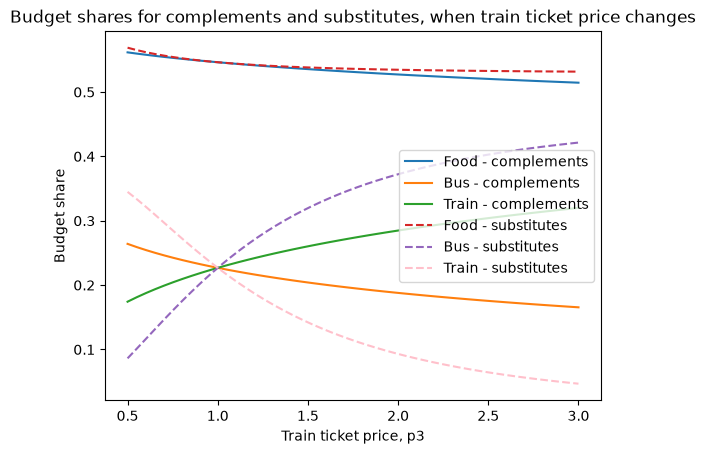

In [12]:
# Plot budget shares

plt.figure()

plt.plot(p3_values, s1_comp, label='Food - complements')
plt.plot(p3_values, s2_comp, label='Bus - complements')
plt.plot(p3_values, s3_comp, label='Train - complements')

plt.plot(p3_values, s1_sub, '--', label='Food - substitutes')
plt.plot(p3_values, s2_sub, '--', label='Bus - substitutes')
plt.plot(p3_values, s3_sub, '--', color='pink', label='Train - substitutes')

plt.title('Budget shares for complements and substitutes, when train ticket price changes')
plt.xlabel('Train ticket price, p3')
plt.ylabel('Budget share')
plt.legend()


plt.show()

3.2 – Budget shares

The figure shows how the optimal budget shares change as the train ticket price increases. When bus and train are complements, a higher train ticket price increases the budget share spent on train, while the budget share spent on bus decreases. When bus and train are substitutes, the opposite occurs: the train budget share decreases and the bus budget share increases as the consumer shifts expenditure towards bus travel. The budget share spent on food changes relatively little in both calibrations.

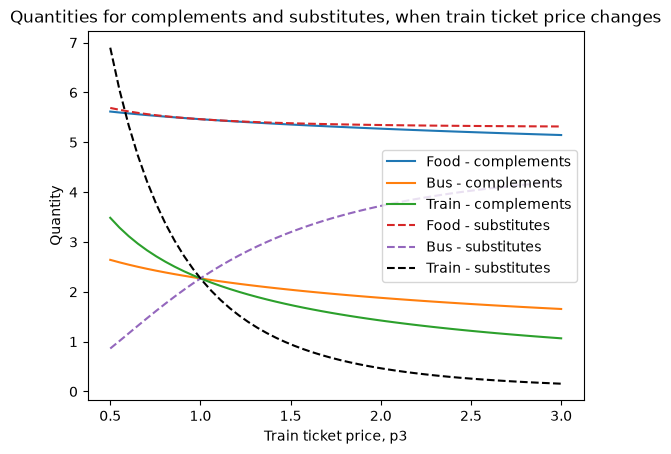

In [13]:
# Plot quantities

plt.figure()

plt.plot(p3_values, x1_comp, label='Food - complements')
plt.plot(p3_values, x2_comp, label='Bus - complements')
plt.plot(p3_values, x3_comp, label='Train - complements')

plt.plot(p3_values, x1_sub, '--', label='Food - substitutes')
plt.plot(p3_values, x2_sub, '--', label='Bus - substitutes')
plt.plot(p3_values, x3_sub, '--', color='black', label='Train - substitutes')

plt.title('Quantities for complements and substitutes, when train ticket price changes')
plt.xlabel('Train ticket price, p3')
plt.ylabel('Quantity')
plt.legend()
plt.show()

3.3 – Bus trips

The effect on the number of bus trips differs clearly between the two calibrations. When bus and train are complements, the number of bus trips decreases as train tickets become more expensive. Since the two modes are consumed together, lower demand for train travel is accompanied by lower demand for bus travel. When bus and train are substitutes, the number of bus trips instead increases because the consumer substitutes away from the more expensive train and towards bus travel. The number of train trips decreases in both calibrations.


In [14]:
# Changes in demand when p3 increases from 0.5 to 3.0

print('Complements:')
print(f'Change in food demand: {x1_comp[-1] - x1_comp[0]:.3f}')
print(f'Change in bus demand: {x2_comp[-1] - x2_comp[0]:.3f}')

print('\nSubstitutes:')
print(f'Change in food demand: {x1_sub[-1] - x1_sub[0]:.3f}')
print(f'Change in bus demand: {x2_sub[-1] - x2_sub[0]:.3f}')

Complements:
Change in food demand: -0.471
Change in bus demand: -0.986

Substitutes:
Change in food demand: -0.372
Change in bus demand: 3.353


3.4 – Food demand

When the train ticket price increases from 0.5 to 3.0, food demand decreases by approximately 0.471 in the complements calibration and by 0.372 in the substitutes calibration. The effect on bus demand is larger: bus demand decreases by approximately 0.986 when bus and train are complements, while it increases by approximately 3.353 when they are substitutes. Thus, changes in the train ticket price have a relatively small effect on food demand compared with bus demand. This reflects that most of the adjustment to a change in the train ticket price takes place within the travel nest, especially when bus and train are substitutes.
